In [39]:
import pandas as pd
data=pd.read_csv('cleaned_dataaa.csv')
df = pd.DataFrame(data)  
df

,Дата вылета,Город отправления,Город назначения,Цена билета,Авиакомпания,Номер рейса,Количество пересадок,День недели,Время в полете (мин),Время суток вылета,Время суток прилета
0,2024-03-02,2,3,0.011817,26,747,0.000000,2,0.037762,3,3
1,2024-03-07,2,3,0.014706,22,7053,0.000000,4,0.037762,2,2
2,2024-03-11,2,3,0.008929,22,7055,0.000000,1,0.039627,3,3
3,2024-03-16,2,3,0.008141,26,703,0.000000,2,0.038228,2,2
4,2024-03-22,2,3,0.009191,26,1703,0.000000,0,0.040559,1,1
...,...,...,...,...,...,...,...,...,...,...,...
5014,2024-03-14,2,5,0.098399,9,5098,0.666667,4,0.783217,2,0
5015,2024-03-14,2,5,0.098699,9,6012,0.666667,4,0.473193,0,3
5016,2024-03-14,2,5,0.099778,3,907,0.333333,4,0.230769,3,1
5017,2024-03-14,2,5,0.100403,15,61802,0.333333,4,0.517483,2,1


In [49]:
missing_values = df.isnull().sum()
missing_values

Дата вылета             0
Город отправления       0
Город назначения        0
Цена билета             0
Авиакомпания            0
Номер рейса             0
Количество пересадок    0
День недели             0
Время в полете (мин)    0
Время суток вылета      0
Время суток прилета     0
dtype: int64

In [40]:
from IPython.display import display
numeric_columns = ["Цена билета", "Количество пересадок", "Время в полете (мин)"]
descriptive_stats = df[numeric_columns].describe().T
display(descriptive_stats)

,count,mean,std,min,25%,50%,75%,max
Цена билета,5019.0,0.074011,0.058190,0.0,0.041419,0.066997,0.092353,1.0
Количество пересадок,5019.0,0.431228,0.258212,0.0,0.333333,0.333333,0.666667,1.0
Время в полете (мин),5019.0,0.427031,0.225251,0.0,0.261072,0.403263,0.608392,1.0


In [75]:
import pandas as pd
from scipy.stats import skew, kurtosis
from IPython.display import display

numeric_columns = ["Цена билета", "Количество пересадок", "Время в полете (мин)"]

median_values = df[numeric_columns].median()
iqr_values = df[numeric_columns].quantile(0.75) - df[numeric_columns].quantile(0.25)
mode_values = df[numeric_columns].mode().iloc[0]
skewness_values = df[numeric_columns].apply(skew)

extra_stats = pd.DataFrame({
    "Медиана": median_values,
    "IQR (межквартильный размах)": iqr_values,
    "Мода": mode_values,
    "Асимметрия (Skewness)": skewness_values,
})

display(extra_stats)

,Медиана,IQR (межквартильный размах),Мода,Асимметрия (Skewness)
Цена билета,0.066997,0.050934,0.098399,5.615960
Количество пересадок,0.333333,0.333333,0.333333,0.160325
Время в полете (мин),0.403263,0.347319,0.372960,0.154673


C:\Users\HP\AppData\Local\Temp\ipykernel_17896\2095247610.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=df["Город отправления"], order=df["Город отправления"].value_counts().index, palette="viridis")


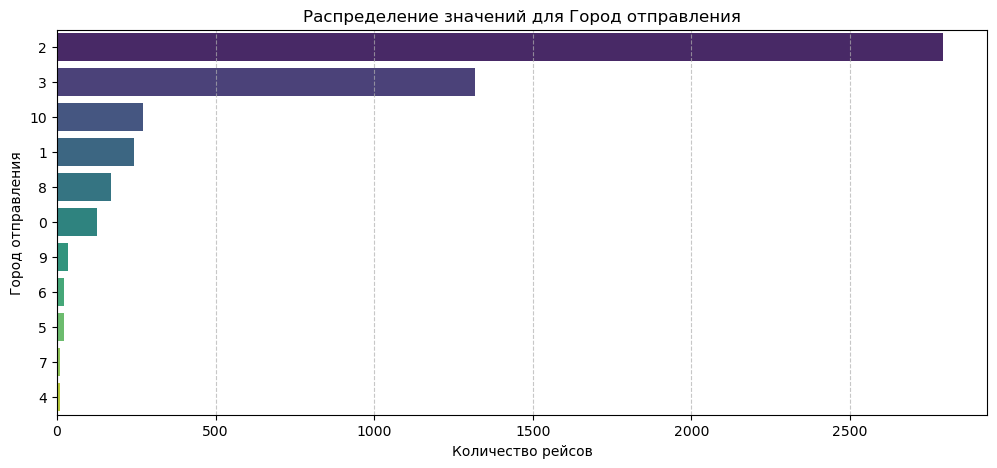

In [42]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 5))
sns.countplot(y=df["Город отправления"], order=df["Город отправления"].value_counts().index, palette="viridis")
plt.xlabel("Количество рейсов")
plt.ylabel("Город отправления")
plt.title("Распределение значений для Город отправления")
plt.grid(axis="x", linestyle="--", alpha=0.7)
plt.show()

**The histogram (countplot) shows the number of flights from each city. Some cities (such as Almaty and Astana) are major aviation hubs with the largest number of departures.**

0-Актау 1-Актобе 2-Алматы 3-Астана 4-Кызылорда 5-Павлодар 6-Семей 7-Талдыкорган 8-Тараз 9-Уральск 10-Усть-Каменогорск 11-Шымкент

C:\Users\HP\AppData\Local\Temp\ipykernel_17896\954168606.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=df["Город назначения"], order=df["Город назначения"].value_counts().index, palette="viridis")


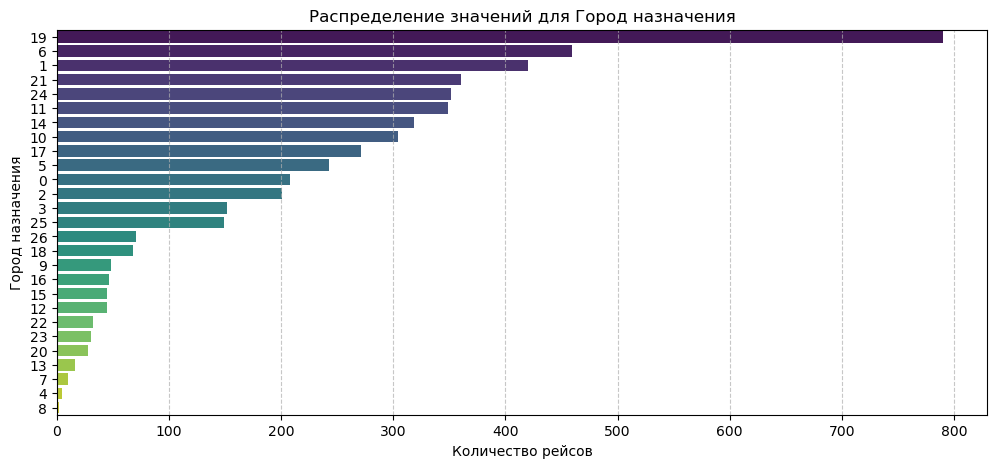

In [43]:
plt.figure(figsize=(12, 5))
sns.countplot(y=df["Город назначения"], order=df["Город назначения"].value_counts().index, palette="viridis")
plt.xlabel("Количество рейсов")
plt.ylabel("Город назначения")
plt.title("Распределение значений для Город назначения")
plt.grid(axis="x", linestyle="--", alpha=0.7)
plt.show()

**The histogram is similar to the previous one, but for destination cities. Routes are most often connected between large cities, which confirms their key role in air traffic.**

0 - Актау, 1 - Алматы, 2 - Анталья, 3 - Астана, 4 - Атырау, 5 - Бангкок, 6 - Дубай, 7 - Жезказган, 8 - Костанай, 9 - Кызылорда, 10 - Лондон, 11 - Москва, 12 - Нью-Йорк, 13 - Павлодар, 14 - Париж, 15 - Рим, 16 - Семей, 17 - Сеул, 18 - Сидней, 19 - Стамбул, 20 - Тараз, 21 - Токио, 22 - Уральск, 23 - Усть-Каменогорск, 24 - Франкфурт-на-Майне, 25 - Шарджа, 26 - Шымкент

C:\Users\HP\AppData\Local\Temp\ipykernel_17896\1943922037.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=df["Авиакомпания"], order=df["Авиакомпания"].value_counts().index, palette="viridis")


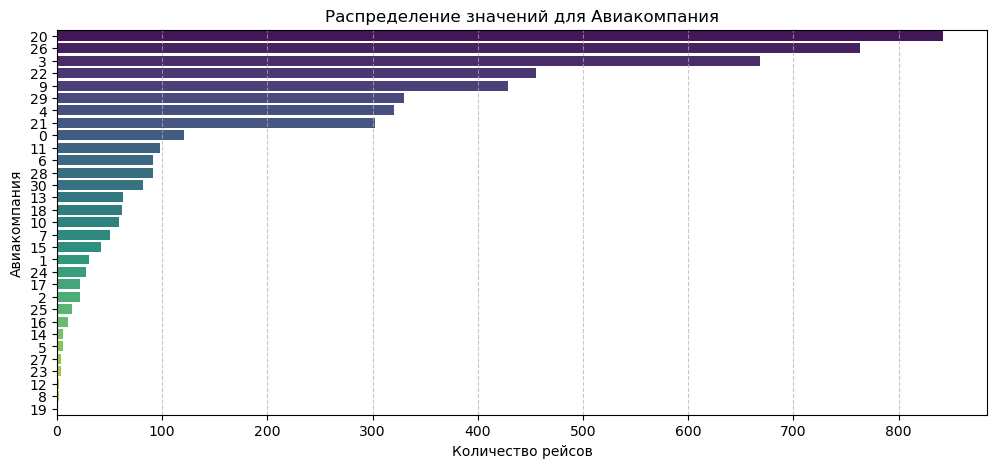

In [44]:
plt.figure(figsize=(12, 5))
sns.countplot(y=df["Авиакомпания"], order=df["Авиакомпания"].value_counts().index, palette="viridis")
plt.xlabel("Количество рейсов")
plt.ylabel("Авиакомпания")
plt.title("Распределение значений для Авиакомпания")
plt.grid(axis="x", linestyle="--", alpha=0.7)
plt.show()

**The histogram shows the number of flights operated by different airlines. Some airlines clearly dominate the market, offering more flights than others.**

0 - AJet, 1 - Aeroflot, 2 - Air Arabia, 3 - Air Astana, 4 - Air China, 5 - Airasia X, 6 - Asiana Airlines, 7 - Azerbaijan Airlines, 8 - Azimuth Airlines, 9 - Canjet Airlines, 10 - China Southern Airlines, 11 - Eastar Jet, 12 - FlyArystan, 13 - FlyDubai, 14 - FlyNas, 15 - Flydubai, 16 - Hannu Air, 17 - Indigo, 18 - Jazeera Airways, 19 - Loong Air, 20 - Lot Polish Airlines, 21 - Lufthansa, 22 - Neos Spa, 23 - Pegasus Airlines, 24 - Qatar Airways, 25 - Qazaq Air, 26 - Red Wings Airlines, 27 - Rossiya-Russian Airlines, 28 - S7 Airlines, 29 - Scat Airlines, 30 - Somon Air

In [51]:
df.dtypes

Дата вылета             datetime64[ns]
Город отправления                int64
Город назначения                 int64
Цена билета                    float64
Авиакомпания                     int64
Номер рейса                      int64
Количество пересадок           float64
День недели                      int64
Время в полете (мин)           float64
Время суток вылета               int64
Время суток прилета              int64
dtype: object

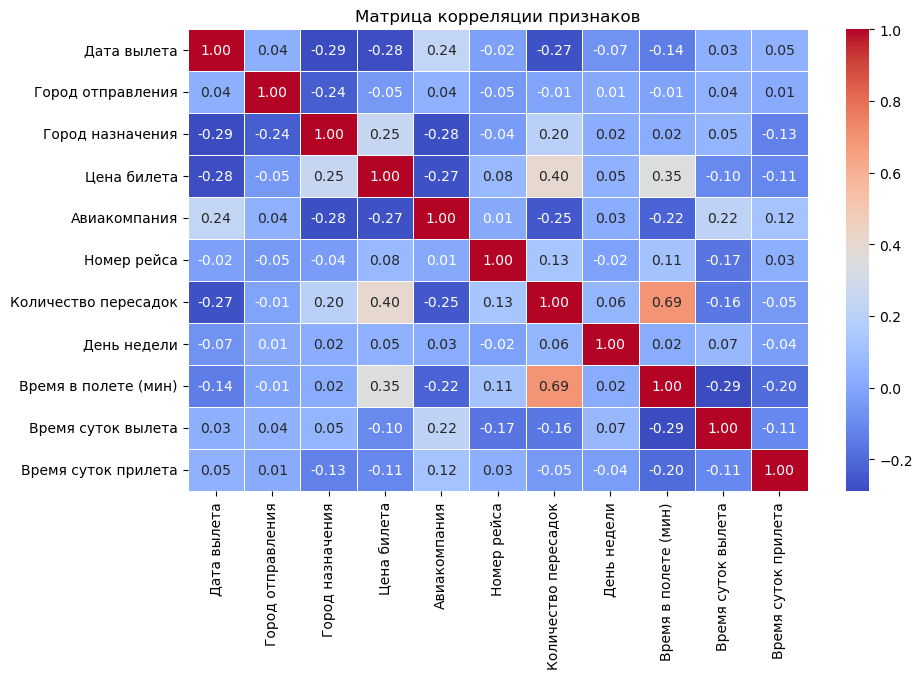

In [52]:
import seaborn as sns
import matplotlib.pyplot as plt

correlation_matrix = df.corr()

plt.figure(figsize=(10, 6))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Матрица корреляции признаков")
plt.show()

**The color map shows the relationship between numerical variables such as ticket price, number of stops, and flight duration. Ticket price has a strong positive correlation with the number of stops and flight duration, confirming the logic of airline pricing.**

C:\Users\HP\AppData\Local\Temp\ipykernel_17896\861401818.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=df["Время суток вылета"], y=df["Цена билета"], palette="magma")


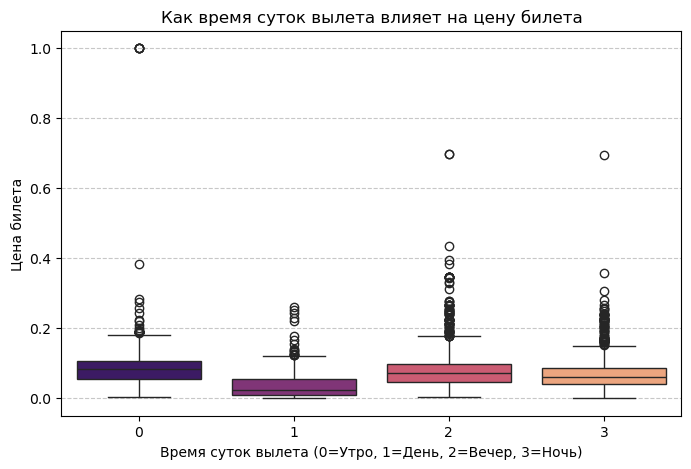

In [54]:
plt.figure(figsize=(8, 5))
sns.boxplot(x=df["Время суток вылета"], y=df["Цена билета"], palette="magma")
plt.xlabel("Время суток вылета (0=Утро, 1=День, 2=Вечер, 3=Ночь)")
plt.ylabel("Цена билета")
plt.title("Как время суток вылета влияет на цену билета")
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.show()

**The boxplot shows the distribution of ticket prices by time of day. Tickets for morning flights may be cheaper, while evening flights are often more expensive.**

C:\Users\HP\AppData\Local\Temp\ipykernel_17896\2574396656.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y=cheapest_routes["Цена билета"], x=cheapest_routes["Город отправления"].astype(str) + " → " + cheapest_routes["Город назначения"].astype(str), palette="Greens_r")


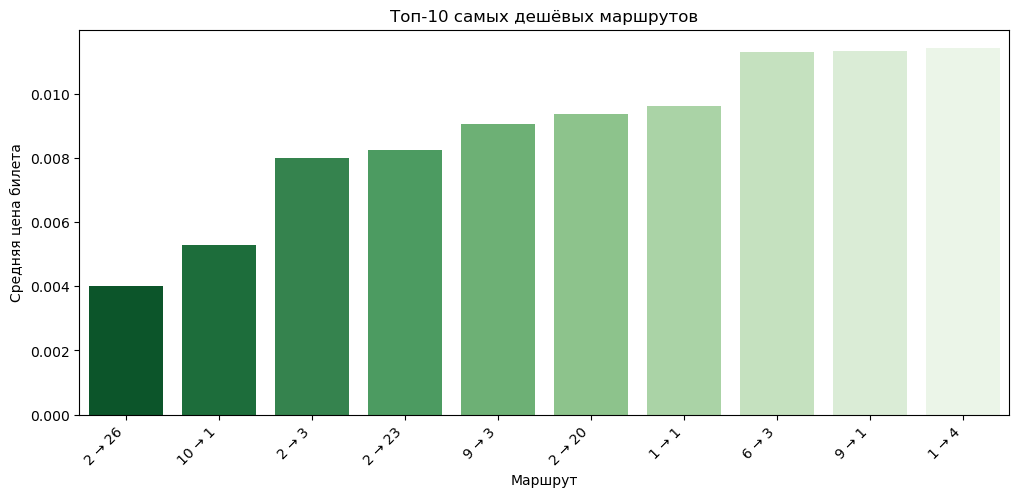

In [57]:
route_prices = df.groupby(["Город отправления", "Город назначения"])["Цена билета"].mean().reset_index()
cheapest_routes = route_prices.nsmallest(10, "Цена билета")
expensive_routes = route_prices.nlargest(10, "Цена билета")

plt.figure(figsize=(12, 5))
sns.barplot(y=cheapest_routes["Цена билета"], x=cheapest_routes["Город отправления"].astype(str) + " → " + cheapest_routes["Город назначения"].astype(str), palette="Greens_r")
plt.xticks(rotation=45, ha="right")
plt.xlabel("Маршрут")
plt.ylabel("Средняя цена билета")
plt.title("Топ-10 самых дешёвых маршрутов")
plt.show()

Топ-10 самых дешёвых маршрутов:
Тараз → Алматы, Алматы → Шымкент, Шымкент → Алматы, Алматы → Тараз, Актобе → Алматы, Алматы → Усть-Каменогорск, Астана → Алматы, Актобе → Атырау, Алматы → Астана, Усть-Каменогорск → Алматы

C:\Users\HP\AppData\Local\Temp\ipykernel_17896\671176931.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y=expensive_routes["Цена билета"], x=expensive_routes["Город отправления"].astype(str) + " → " + expensive_routes["Город назначения"].astype(str), palette="Reds_r")


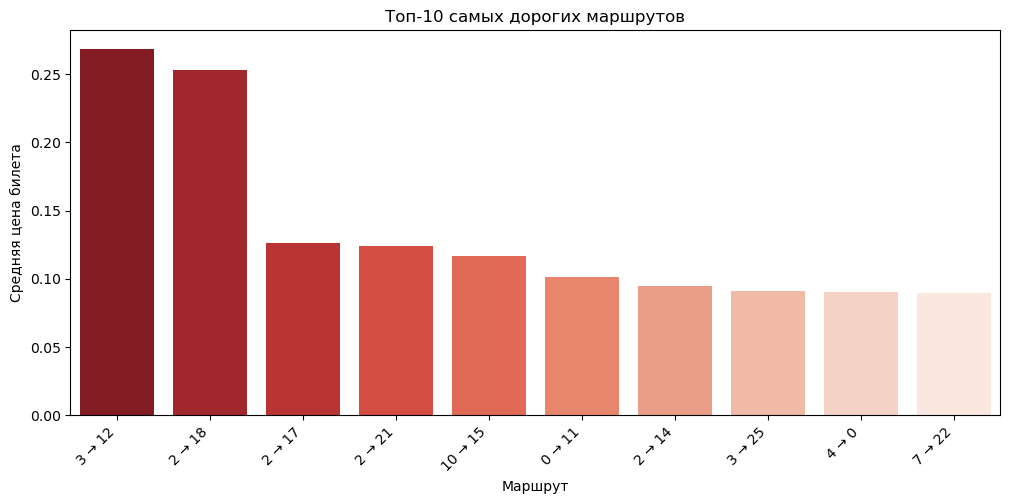

In [58]:
plt.figure(figsize=(12, 5))
sns.barplot(y=expensive_routes["Цена билета"], x=expensive_routes["Город отправления"].astype(str) + " → " + expensive_routes["Город назначения"].astype(str), palette="Reds_r")
plt.xticks(rotation=45, ha="right")
plt.xlabel("Маршрут")
plt.ylabel("Средняя цена билета")
plt.title("Топ-10 самых дорогих маршрутов")
plt.show()

Топ-10 самых дорогих маршрутов:
Астана → Нью-Йорк, Алматы → Сидней, Алматы → Токио, Алматы → Сеул, Шымкент → Рим, Актобе → Москва, Алматы → Париж, Кызылорда → Актау, Астана → Шарджа, Тараз → Уральск

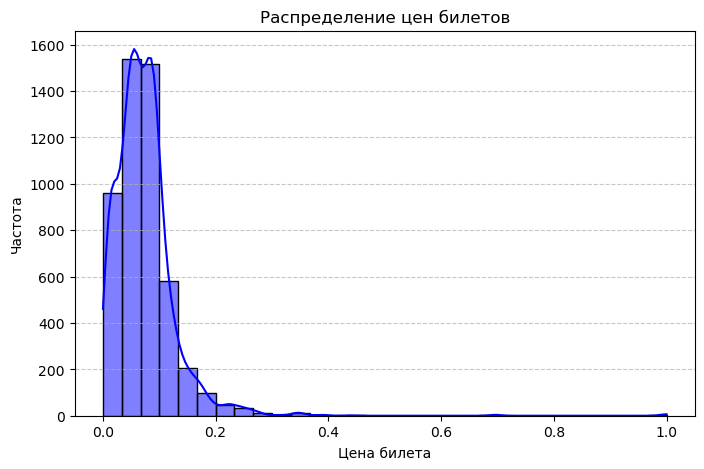

In [59]:
plt.figure(figsize=(8, 5))
sns.histplot(df["Цена билета"], bins=30, kde=True, color="blue")
plt.xlabel("Цена билета")
plt.ylabel("Частота")
plt.title("Распределение цен билетов")
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.show()

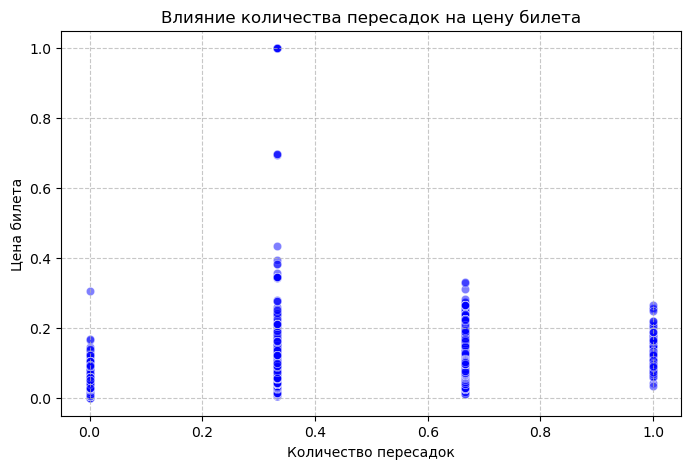

In [62]:
plt.figure(figsize=(8, 5))
sns.scatterplot(x=df["Количество пересадок"], y=df["Цена билета"], alpha=0.5, color="blue")
plt.xlabel("Количество пересадок")
plt.ylabel("Цена билета")
plt.title("Влияние количества пересадок на цену билета")
plt.grid(True, linestyle="--", alpha=0.7)
plt.show()

**A scatter plot displaying the relationship between the number of layovers and ticket price. Flights with more layovers tend to be more expensive, indicating that direct flights are often the more cost-effective option.**

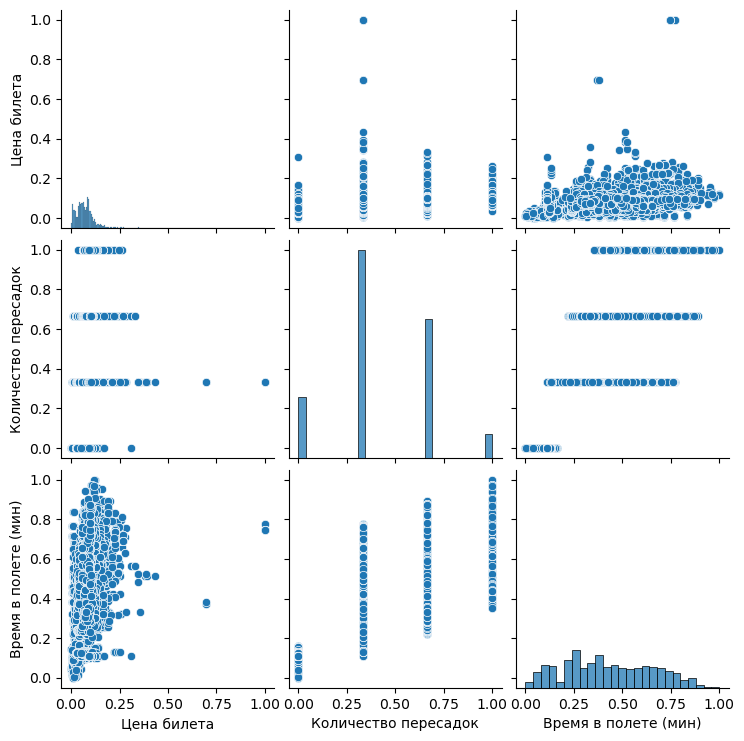

In [63]:
sns.pairplot(df[["Цена билета", "Количество пересадок", "Время в полете (мин)"]])
plt.show()

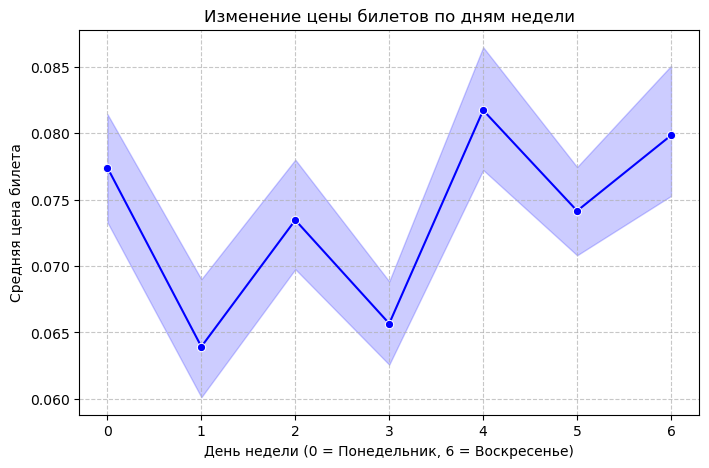

In [65]:
plt.figure(figsize=(8, 5))
sns.lineplot(x=df["День недели"], y=df["Цена билета"], marker="o", color="blue")
plt.xlabel("День недели (0 = Понедельник, 6 = Воскресенье)")
plt.ylabel("Средняя цена билета")
plt.title("Изменение цены билетов по дням недели")
plt.grid(True, linestyle="--", alpha=0.7)
plt.show()

**A line chart illustrating how ticket prices fluctuate depending on the day of the week. Flights tend to be more expensive on weekends, likely due to higher demand from leisure travelers. On Tuesdays, Thursdays and Saturdays the prices are clearly lower**

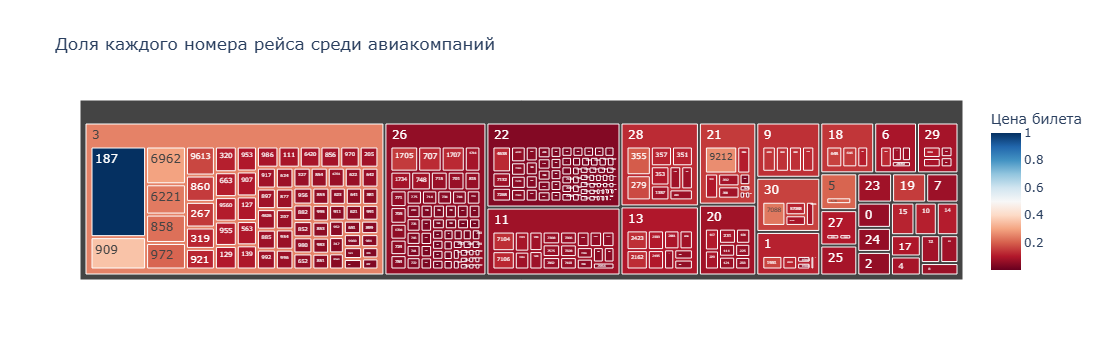

In [73]:
import plotly.express as px

# Группируем данные для Treemap (древовидной карты)
df_treemap = df.groupby(["Авиакомпания", "Номер рейса"])["Цена билета"].mean().reset_index()

# Создаём Treemap Chart
fig = px.treemap(df_treemap, 
                 path=["Авиакомпания", "Номер рейса"], 
                 values="Цена билета",
                 title="Доля каждого номера рейса среди авиакомпаний",
                 color="Цена билета", 
                 color_continuous_scale="RdBu")

# Отображаем график
fig.show()

**A treemap visualizing how different airlines contribute to the total number of flights and their pricing structure. Certain airlines dominate specific routes, and flights with the same airline may vary significantly in price depending on demand and destination.**

0 - AJet, 1 - Aeroflot, 2 - Air Arabia, 3 - Air Astana, 4 - Air China, 5 - Airasia X, 6 - Asiana Airlines, 7 - Azerbaijan Airlines, 8 - Azimuth Airlines, 9 - Canjet Airlines, 10 - China Southern Airlines, 11 - Eastar Jet, 12 - FlyArystan, 13 - FlyDubai, 14 - FlyNas, 15 - Flydubai, 16 - Hannu Air, 17 - Indigo, 18 - Jazeera Airways, 19 - Loong Air, 20 - Lot Polish Airlines, 21 - Lufthansa, 22 - Neos Spa, 23 - Pegasus Airlines, 24 - Qatar Airways, 25 - Qazaq Air, 26 - Red Wings Airlines, 27 - Rossiya-Russian Airlines, 28 - S7 Airlines, 29 - Scat Airlines, 30 - Somon Air

# Conclusion:
This analysis explores airfare trends based on key flight attributes, including departure/arrival cities, airlines, ticket prices, flight durations, and layovers. The data was cleaned to remove anomalies, categorical variables were encoded, and numerical features were scaled for better insights.

Key findings reveal that ticket prices are highly influenced by the number of layovers and the day of the week, with weekends generally being more expensive. Certain airlines consistently charge higher fares, possibly due to demand, service quality, or exclusivity.

Through scatter plots, correlation heatmaps, and pair plots, we observed strong relationships between flight duration, layovers, and ticket pricing. Time-series analysis confirmed seasonal and weekly fluctuations in airfare, while custom visualizations like Treemaps and Sunburst charts provided a deeper look at airline-specific pricing structures.

These insights can be applied to develop a personalized flight recommendation system, optimize airline pricing strategies, and improve route planning. This study offers a data-driven foundation for predictive modeling, business intelligence, and competitive market analysis in the aviation industry.